# Collaborative Filtering Benchmark (Simplified)

**Goal:** Compare 4 similarity measures  
(Cosine, Adjusted‑Cosine, Pearson, Jaccard & MSD) for both **user‑based** and **item‑based** memory CF on MovieLens 100K Dataset.

Metrics  
* Rating prediction: **RMSE**, **MAE**  
* Top‑N quality: **Precision**, **Recall**, **F1**

Just run the notebook top‑to‑bottom.

> **Note:** This notebook was developed using **Python 3.10** to support the surprise library.

## 1. Imports and Setup

We begin by importing the necessary libraries:

- **pandas**, **numpy**: data handling and computation  
- **surprise**: for collaborative filtering algorithms and evaluation  
- **sklearn**: for computing pairwise similarities  
- **collections**: for utility structures (e.g., `defaultdict`)
- **matplotlib**, **scipy**: for visualizating plots  

These will enable us to build, evaluate, and compare different memory-based collaborative filtering models.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from surprise import Dataset, Reader, KNNBasic, SVD, accuracy
from surprise.model_selection import train_test_split
from sklearn.metrics.pairwise import pairwise_distances, cosine_similarity
from collections import defaultdict

## 2. Data Loading and Preprocessing

We define a function to load and preprocess the MovieLens data:

- Reads the dataset from CSV.
- Drops the `timestamp` column (if present) as it's not relevant for collaborative filtering.
- Filters out movies with fewer than 5 ratings to reduce noise and improve performance.
- Converts the cleaned DataFrame into a Surprise-compatible dataset using a rating scale of 1 to 5.

This prepares the data for use in memory-based collaborative filtering models.


In [6]:
def load_data(path):
    df = pd.read_csv(path)
    
    # Drop timestamp if present, since it's not needed for the analysis
    if "timestamp" in df.columns:
        df = df.drop(columns=["timestamp"])
    
    # Filter out movies with fewer than 5 ratings
    item_counts = df['movieId'].value_counts()
    popular_items = item_counts[item_counts >= 5].index
    df = df[df['movieId'].isin(popular_items)]
    
    # Load into Surprise Dataset
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)
    
    return df, data

## 3. Evaluation Function

To assess the performance of our collaborative filtering models, we define an evaluation function that computes:

- **RMSE** and **MAE**: for rating prediction accuracy  
- **Precision**, **Recall**, and **F1‑Score**: for top‑N recommendation quality

### Method Overview:
- A prediction is considered **relevant** if the true rating ≥ threshold (default: 4.0).
- For each user, we extract the **top-N** highest predicted ratings (default: N = 10).
- We compare these recommendations with the set of truly relevant items to compute:
  - **Precision**: proportion of recommended items that are relevant
  - **Recall**: proportion of relevant items that are recommended
  - **F1‑Score**: harmonic mean of precision and recall

This function returns a complete set of metrics for model benchmarking.


In [7]:
def evaluate(predictions, threshold=4.0, top_n=10):
    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)
    
    user_relevant = defaultdict(set)
    user_preds = defaultdict(list)
    
    for uid, iid, true_r, pred_r, _ in predictions:
        if true_r >= threshold:
            user_relevant[uid].add(iid)
        user_preds[uid].append((iid, pred_r))
    
    precisions, recalls = [], []
    for uid in user_preds:
        rec_items = [iid for (iid, _) in sorted(user_preds[uid], key=lambda x: x[1], reverse=True)[:top_n]]
        relevant = user_relevant.get(uid, set())
        if not relevant:
            continue
        tp = len(set(rec_items) & relevant)
        precisions.append(tp / len(rec_items))
        recalls.append(tp / len(relevant))
    
    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0
    f1 = (2 * avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) else 0
    
    return rmse, mae, avg_precision, avg_recall, f1

## 4. Similarity Metrics Outside of Library

### 4.1 Adjusted Cosine Similarity

This function implements **Adjusted Cosine Similarity** for collaborative filtering.

#### Key Steps:
- Constructs a user‑item rating matrix from the training set.
- Normalizes ratings by subtracting user (or item) means to remove individual rating bias.
- Computes cosine similarity on the normalized matrix.
- For each `(user, item)` pair in the test set:
  - Identifies the top‑k most similar users (or items).
  - Aggregates their ratings using a weighted average.
  - If no neighbors are found, uses the global mean rating.

This approach adjusts for rating scale differences across users/items, improving similarity accuracy.


In [8]:
def adjusted_cosine_predictions(trainset, testset, k, user_based=True):
    n_users, n_items = trainset.n_users, trainset.n_items

    # Build rating matrix
    rating_matrix = np.full((n_users, n_items), np.nan)
    for u in range(n_users):
        for i, r in trainset.ur[u]:
            rating_matrix[u, i] = r

    if user_based:
        # Subtract user means
        user_means = np.nanmean(rating_matrix, axis=1).reshape(-1, 1)
        norm_ratings = rating_matrix - user_means
        norm_ratings[np.isnan(norm_ratings)] = 0
        sim_matrix = cosine_similarity(norm_ratings)
    else:
        # Subtract item means
        item_means = np.nanmean(rating_matrix, axis=0).reshape(1, -1)
        norm_ratings = rating_matrix - item_means
        norm_ratings[np.isnan(norm_ratings)] = 0
        sim_matrix = cosine_similarity(norm_ratings.T)

    predictions = []
    for uid, iid, true_r in testset:
        try:
            u_inner = trainset.to_inner_uid(uid)
            i_inner = trainset.to_inner_iid(iid)
        except ValueError:
            predictions.append((uid, iid, true_r, None, {}))
            continue

        neighbors = []
        if user_based:
            for v_inner, r in trainset.ir[i_inner]:  # all users who rated item
                if v_inner == u_inner:
                    continue
                sim_score = sim_matrix[u_inner, v_inner]
                neighbors.append((sim_score, r))
        else:
            for j_inner, r in trainset.ur[u_inner]:  # all items rated by user
                if j_inner == i_inner:
                    continue
                sim_score = sim_matrix[i_inner, j_inner]
                neighbors.append((sim_score, r))

        neighbors.sort(reverse=True, key=lambda x: x[0])
        neighbors = neighbors[:k]

        sum_sim = sum_r = 0
        for sim_score, r in neighbors:
            sum_sim += abs(sim_score)
            sum_r += sim_score * r

        pred = sum_r / sum_sim if sum_sim > 0 else trainset.global_mean
        predictions.append((uid, iid, true_r, pred, {}))

    return [p for p in predictions if p[3] is not None]

### 4.2 Jaccard Similarity

This function implements **Jaccard Similarity** using binary interaction data.

#### Key Steps:
- Builds a binary matrix indicating whether a user has rated an item (1) or not (0).
- Computes Jaccard similarity between users (or items) based on overlap in rated items.
- For each `(user, item)` in the test set:
  - Gathers top‑k most similar users/items who rated the target.
  - Uses similarity-weighted average of their ratings to estimate the prediction.
  - Falls back to global mean if no neighbors are available.

Jaccard is well-suited for capturing **implicit feedback patterns** based on co‑rating behavior.


In [9]:
def jaccard_predictions(trainset, testset, k, user_based=True):
    if user_based:
        binary_matrix = np.zeros((trainset.n_users, trainset.n_items))
        for u in range(trainset.n_users):
            for i, _ in trainset.ur[u]:
                binary_matrix[u, i] = 1
        jaccard_sim = 1 - pairwise_distances(binary_matrix, metric='jaccard')
    else:
        binary_matrix = np.zeros((trainset.n_items, trainset.n_users))
        for i in range(trainset.n_items):
            for u, _ in trainset.ir[i]:
                binary_matrix[i, u] = 1
        jaccard_sim = 1 - pairwise_distances(binary_matrix, metric='jaccard')

    predictions = []

    for uid, iid, true_r in testset:
        try:
            u_inner = trainset.to_inner_uid(uid)
            i_inner = trainset.to_inner_iid(iid)
        except ValueError:
            predictions.append((uid, iid, true_r, None, {}))
            continue

        neighbors = []
        if user_based:
            for v_inner, r in trainset.ir[i_inner]:  # all users who rated item
                if v_inner == u_inner:
                    continue
                sim_score = jaccard_sim[u_inner, v_inner]
                neighbors.append((sim_score, r))
        else:
            for j_inner, r in trainset.ur[u_inner]:  # all items rated by user
                if j_inner == i_inner:
                    continue
                sim_score = jaccard_sim[i_inner, j_inner]
                neighbors.append((sim_score, r))

        neighbors.sort(reverse=True, key=lambda x: x[0])
        neighbors = neighbors[:k]

        sum_sim = sum_r = 0
        for sim_score, r in neighbors:
            sum_sim += sim_score
            sum_r += sim_score * r

        pred = sum_r / sum_sim if sum_sim > 0 else trainset.global_mean
        predictions.append((uid, iid, true_r, pred, {}))

    return [p for p in predictions if p[3] is not None]

## 5 Running Collaborative Filtering Experiments

We define a unified function to benchmark different **similarity measures** and **neighborhood sizes (k)**.

### Function Overview:
- Iterates over a list of similarity configurations and `k` values.
- For each combination:
  - Selects the appropriate prediction method:
    - `adjusted_cosine_predictions`
    - `jaccard_predictions`
    - or built-in `KNNBasic` from Surprise for other metrics (e.g., cosine, MSD, Pearson)
  - Generates predictions on the test set.
  - Evaluates the results using RMSE, MAE, Precision, Recall, and F1.

### Output:
Returns a Pandas `DataFrame` containing all evaluation metrics, enabling easy comparison across:
- Similarity types
- User‑based vs. item‑based filtering
- Neighborhood sizes


In [10]:
def run_cf_experiments(trainset, testset, similarities, k_values):
    results = []

    for sim in similarities:
        for k in k_values:
            print(f"Running: sim={sim['name']}, user_based={sim['user_based']}, k={k}")

            if sim['name'] == 'jaccard':
                preds = jaccard_predictions(trainset, testset, k, user_based=sim['user_based'])
            elif sim['name'] == 'adjusted_cosine':
                preds = adjusted_cosine_predictions(trainset, testset, k, user_based=sim['user_based'])
            else:
                algo_cls = KNNBasic
                algo = algo_cls(k=k, sim_options=sim)
                algo.fit(trainset)
                preds = algo.test(testset)

            rmse, mae, prec, rec, f1 = evaluate(preds)
            results.append({
                'similarity': sim['name'],
                'user_based': sim['user_based'],
                'k': k,
                'RMSE': rmse,
                'MAE': mae,
                'Precision': prec,
                'Recall': rec,
                'F1': f1
            })

    return pd.DataFrame(results)

### 5.1 Model-Based Benchmark: FunkSVD

To compare memory-based methods with a **model-based approach**, we implement evaluation using **FunkSVD** (a matrix factorization algorithm).

#### Key Steps:
- Iterates over a list of latent factor sizes (`n_factors_list`).
- Trains a `Surprise.SVD` model (which performs gradient descent-based matrix factorization).
- Evaluates each model on the test set using the same metrics:
  - **RMSE**, **MAE** for rating prediction
  - **Precision**, **Recall**, **F1** for top‑N recommendations

#### Output:
Returns a `DataFrame` summarizing performance across different latent dimensionalities, enabling comparison with memory-based collaborative filtering.


In [11]:
def run_funksvd(trainset, testset, n_factors_list, label="FunkSVD"):
    results = []

    for n_factors in n_factors_list:
        algo = SVD(n_factors=n_factors, random_state=42)
        algo.fit(trainset)
        preds = algo.test(testset)
        rmse, mae, prec, rec, f1 = evaluate(preds)
        results.append({
            'model': label,
            'n_factors': n_factors,
            'RMSE': rmse,
            'MAE': mae,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })

    return pd.DataFrame(results)

### 5.2 Experiment

We define the parameters for our collaborative filtering experiments.

#### Similarity Settings:
We evaluate **10 configurations** combining the following:
- **Similarity Metrics**: Cosine, Adjusted Cosine, Pearson, Jaccard, MSD
- **User‑Based vs. Item‑Based**: Both perspectives are tested for each metric

In [12]:
similarities = [
    {'name': 'cosine', 'user_based': True},
    {'name': 'cosine', 'user_based': False},
    {'name': 'adjusted_cosine', 'user_based': True},
    {'name': 'adjusted_cosine', 'user_based': False},
    {'name': 'pearson', 'user_based': True},
    {'name': 'pearson', 'user_based': False},
    {'name': 'jaccard', 'user_based': True},
    {'name': 'jaccard', 'user_based': False},
    {'name': 'msd', 'user_based': True},
    {'name': 'msd', 'user_based': False},
]

k_values = [5, 10, 20, 30, 50, 100, 150]
n_factors_list = [10, 20, 50, 100, 150]

### 5.3 Load and Split Data

We load the MovieLens ratings dataset and prepare it for training and evaluation.

#### Steps:
- Load the preprocessed ratings data using `load_data(...)`
- Perform an **80/20 train-test split** using `Surprise`'s `train_test_split`
- Print basic statistics about the dataset

This split allows us to simulate a realistic recommendation setting where predictions are made on unseen user‑item interactions.


In [13]:
df, data = load_data("data/ratings.csv")
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Loaded {len(df):,} ratings from {df['userId'].nunique()} users and {df['movieId'].nunique()} movies\n")
print("Preview of data:\n", df.head(10))

Loaded 90,274 ratings from 610 users and 3650 movies

Preview of data:
    userId  movieId  rating
0       1        1     4.0
1       1        3     4.0
2       1        6     4.0
3       1       47     5.0
4       1       50     5.0
5       1       70     3.0
6       1      101     5.0
7       1      110     4.0
8       1      151     5.0
9       1      157     5.0


### 5.4 Run Memory-Based CF Experiments

We execute the full benchmark for **memory-based collaborative filtering** using all configured similarity metrics and neighborhood sizes.

#### Steps:
- Call `run_cf_experiments(...)` with the defined `similarities` and `k_values`
- Save results to CSV for further analysis
- Display the collected performance metrics

This provides a comprehensive evaluation of how each similarity measure and neighborhood size affects both **prediction accuracy** and **recommendation quality**.

In [14]:
cf_results = run_cf_experiments(trainset, testset, similarities, k_values)
cf_results.to_csv('results/cf_experiment_results.csv', index=False)
print(cf_results)

Running: sim=cosine, user_based=True, k=5
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=10
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=20
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=30
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=50
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=100
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=150
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=False, k=5
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=False, k=10
Com

c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=jaccard, user_based=True, k=10


c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=jaccard, user_based=True, k=20


...

Running: sim=jaccard, user_based=False, k=100


c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=jaccard, user_based=False, k=150


c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=msd, user_based=True, k=5
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=10
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=20
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=30
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=50
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=100
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=150
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=False, k=5
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=False, k=10
Computing the msd similarity matrix...
Done computing 

### 5.5 Run Model-Based CF: FunkSVD

We now benchmark the **FunkSVD** model across different numbers of latent factors.

#### Steps:
- Call `run_funksvd(...)` with the defined list of `n_factors`
- Save the results to CSV for reproducibility
- Print the performance metrics for inspection

This experiment allows us to compare **model-based** collaborative filtering against the earlier **memory-based** approaches.


In [15]:
funk_results = run_funksvd(trainset, testset, n_factors_list)
funk_results.to_csv('results/funk_model_experiment_results.csv', index=False)
print(funk_results)

     model  n_factors      RMSE       MAE  Precision    Recall        F1
0  FunkSVD         10  0.849093  0.652629   0.674796  0.687237  0.680960
1  FunkSVD         20  0.850123  0.654468   0.673599  0.686390  0.679935
2  FunkSVD         50  0.849421  0.652574   0.671377  0.684695  0.677971
3  FunkSVD        100  0.852791  0.655539   0.672574  0.685591  0.679020
4  FunkSVD        150  0.855590  0.656793   0.668813  0.685591  0.677098


### 5.6 Sparse Data Experiment

To evaluate the **robustness** of collaborative filtering methods under **sparse conditions**, we repeat all experiments on a reduced dataset.

#### Steps:
- Randomly sample **20% of the original ratings** to simulate data sparsity.
- Reuse the `load_data(...)` function and manually override `raw_ratings`.
- Perform an 80/20 train-test split on this sparse dataset.
- Run both:
  - `run_cf_experiments(...)` for memory-based methods
  - `run_funksvd(...)` for the model-based FunkSVD approach

#### Purpose:
This experiment helps assess how each method handles **limited rating data**, which is common in real-world recommendation systems.


In [16]:
sparse_df = df.sample(frac=0.2, random_state=42)
_, sparse_data = load_data("data/ratings.csv")
sparse_data.raw_ratings = [(str(u), str(i), float(r), 0) for u, i, r in zip(sparse_df['userId'], sparse_df['movieId'], sparse_df['rating'])]
sparse_trainset, sparse_testset = train_test_split(sparse_data, test_size=0.2, random_state=42)

print(f"Sparse data: {len(sparse_df):,} ratings from {sparse_df['userId'].nunique()} users and {sparse_df['movieId'].nunique()} movies")

sparse_cf_results = run_cf_experiments(sparse_trainset, sparse_testset, similarities, k_values)
sparse_cf_results.to_csv('results/cf_sparcity_experiment_results.csv', index=False)
print(sparse_cf_results)

sparse_funk_results = run_funksvd(sparse_trainset, sparse_testset, n_factors_list, label="FunkSVD (sparse)")
sparse_funk_results.to_csv('results/funk_model_experiment_results_sparse.csv', index=False)
print(sparse_funk_results)

Sparse data: 18,055 ratings from 610 users and 3271 movies
Running: sim=cosine, user_based=True, k=5
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=10
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=20
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=30
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=50
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=100
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=True, k=150
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running: sim=cosine, user_based=False, k=5
Computing the cosine similarity matrix...
Done computing similar

c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=jaccard, user_based=True, k=10


c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=jaccard, user_based=True, k=20


...

Running: sim=jaccard, user_based=False, k=100


c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=jaccard, user_based=False, k=150


c:\Users\victo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Running: sim=msd, user_based=True, k=5
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=10
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=20
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=30
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=50
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=100
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=True, k=150
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=False, k=5
Computing the msd similarity matrix...
Done computing similarity matrix.
Running: sim=msd, user_based=False, k=10
Computing the msd similarity matrix...
Done computing 

### 6. Visualize Memory-Based CF Results

To analyze the performance of memory-based collaborative filtering, we generate visualizations that show how different **similarity metrics**, **collaborative filtering types** (user-based vs item-based), and **neighborhood sizes (k)** impact the evaluation metrics.

#### Evaluation Metrics:
- **RMSE**
- **MAE**
- **Precision**
- **Recall**
- **F1-score**

For each metric, we create a line plot:
- One line per similarity measure
- Line style distinguishes user-based (solid) from item-based (dashed)
- Curves are smoothed when possible to show trends clearly

This visualization provides insight into:
- Which similarity metrics perform best
- How performance varies with `k`
- Whether user-based or item-based filtering is more effective
- How sparsity affects results when comparing to a reduced dataset


In [26]:
def plot_cf_results(df, title_prefix=''):
    df['type'] = df['user_based'].map({True: 'User-Based', False: 'Item-Based'})

    line_styles = {'User-Based': '-', 'Item-Based': '--'}
    metrics = ['RMSE', 'MAE', 'Precision', 'Recall', 'F1']
    similarities = df['similarity'].unique()

    for metric in metrics:
        plt.figure(figsize=(10, 6))

        for cf_type in ['User-Based', 'Item-Based']:
            subset = df[df['type'] == cf_type]

            for similarity in similarities:
                data = subset[subset['similarity'] == similarity]
                x = data['k'].values
                y = data[metric].values

                if len(x) >= 3:
                    sorted_indices = np.argsort(x)
                    x_sorted = x[sorted_indices]
                    y_sorted = y[sorted_indices]
                    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 300)
                    spline = make_interp_spline(x_sorted, y_sorted, k=2)
                    y_smooth = spline(x_smooth)

                    plt.plot(
                        x_smooth,
                        y_smooth,
                        label=f"{similarity} ({cf_type})",
                        linestyle=line_styles[cf_type]
                    )
                else:
                    plt.plot(
                        x,
                        y,
                        label=f"{similarity} ({cf_type})",
                        linestyle=line_styles[cf_type],
                        marker='o'
                    )

        plt.title(f'{title_prefix}{metric} vs k for CF Types')
        plt.xlabel('k (Neighborhood Size)')
        plt.ylabel(metric)
        plt.legend(title='Similarity + Type')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

### 6.1 Memory-Based CF Results
This section shows plots for the original `cf_results` dataset.

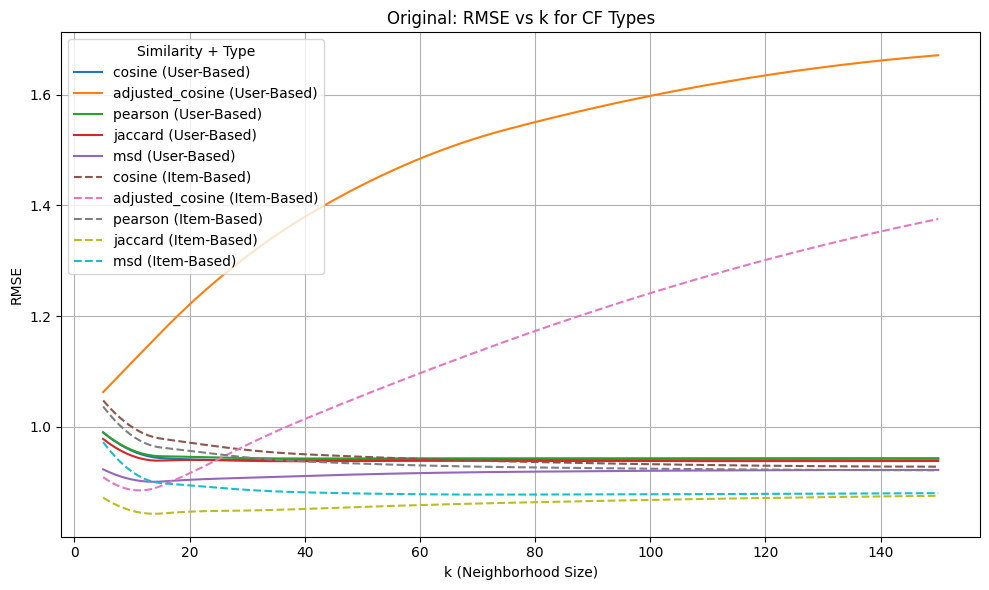

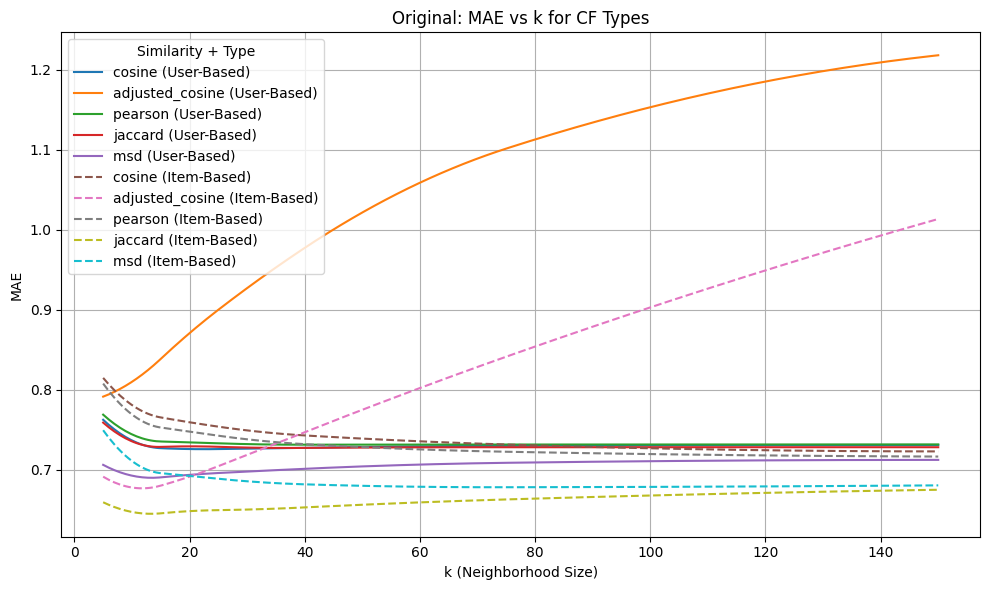

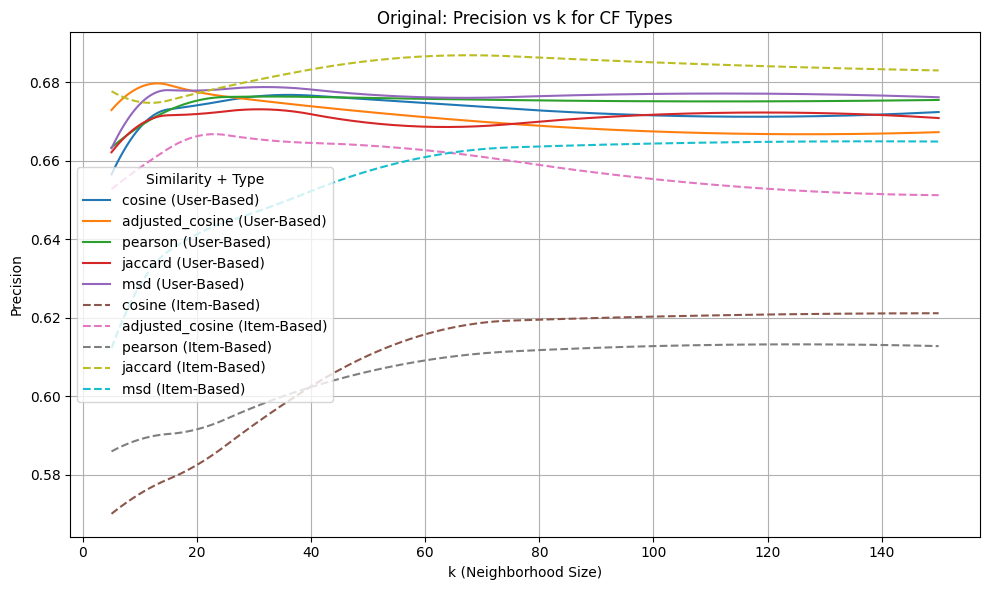

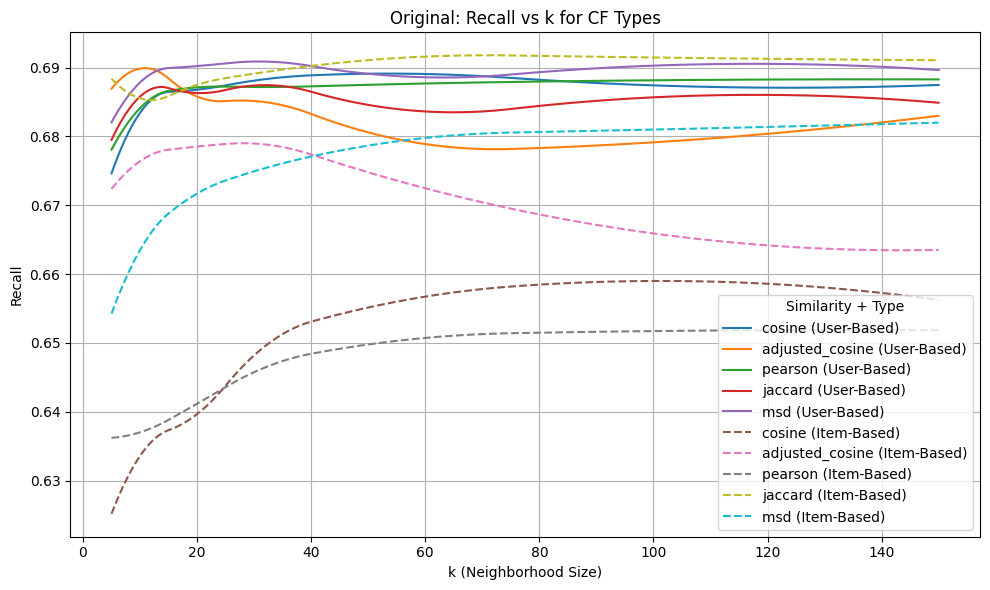

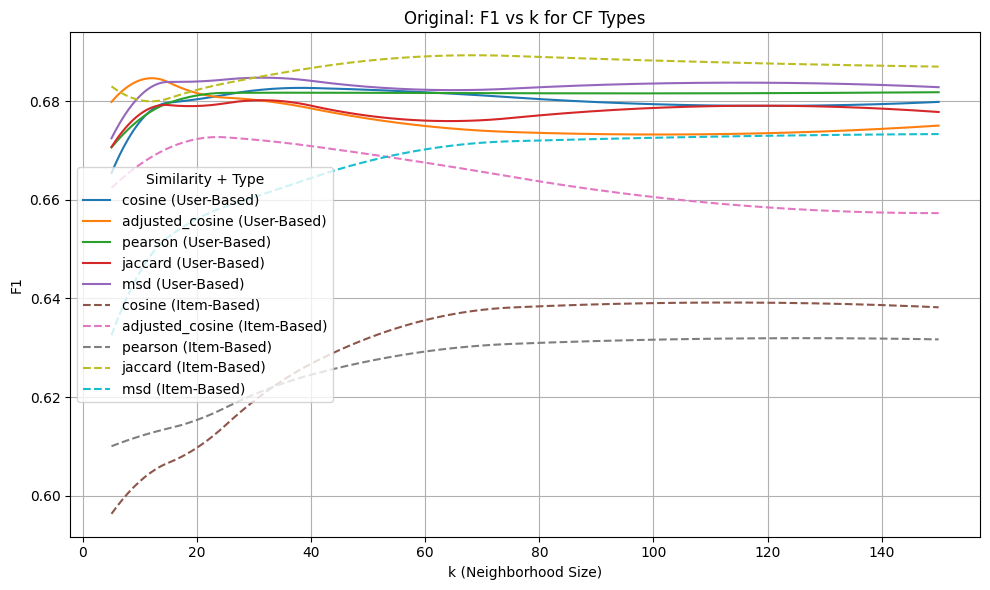

In [28]:
plot_cf_results(cf_results, title_prefix='Original: ')

### 6.2 Memory-Based CF Results with Sparcity
This section visualizes results from the sparsity experiment.

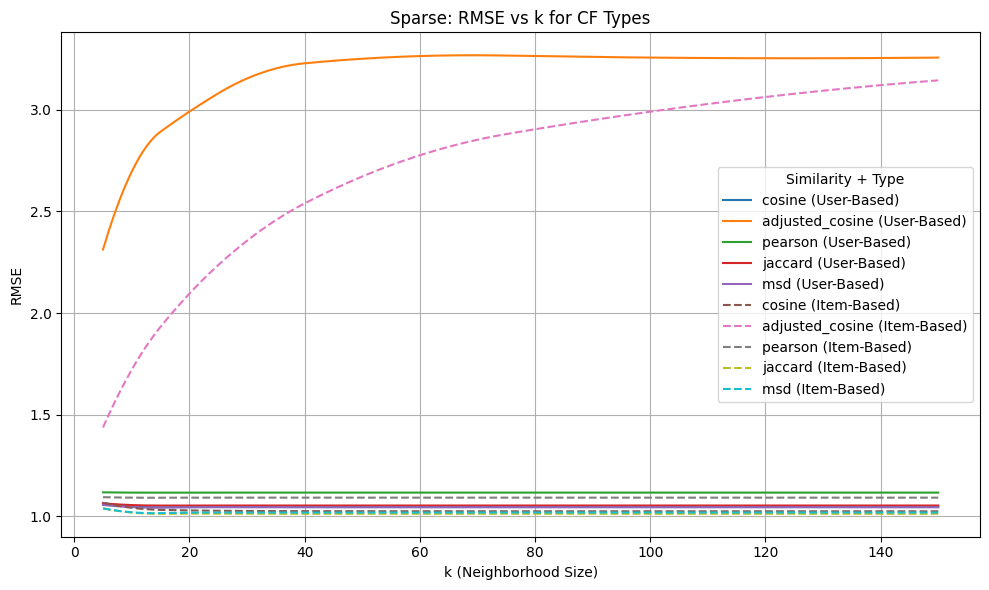

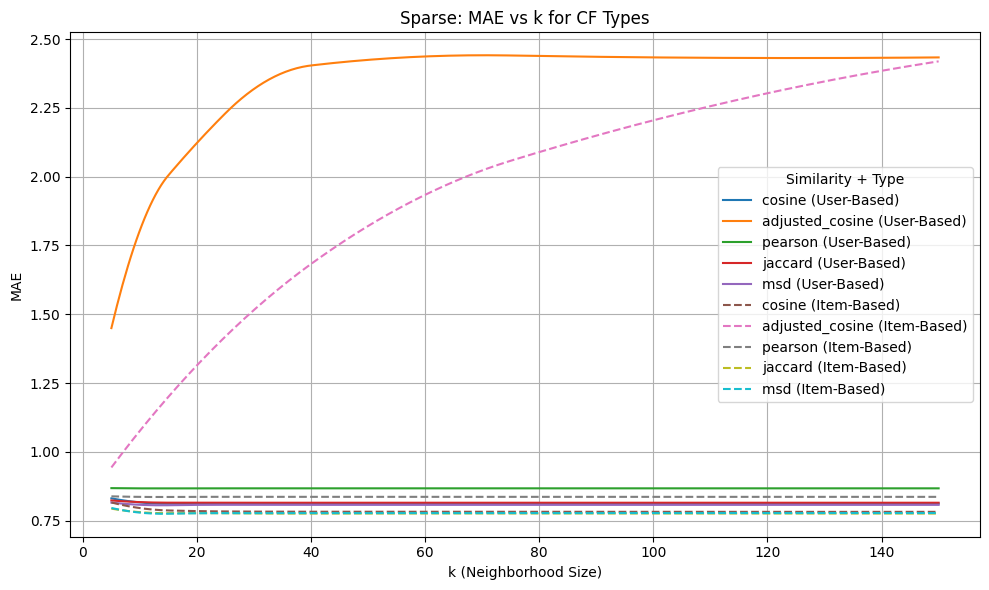

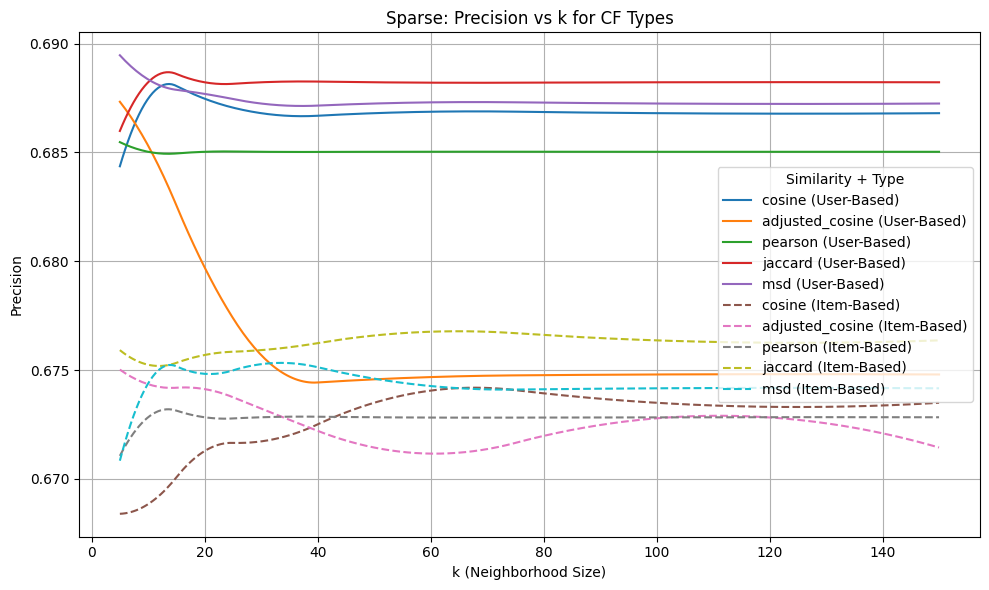

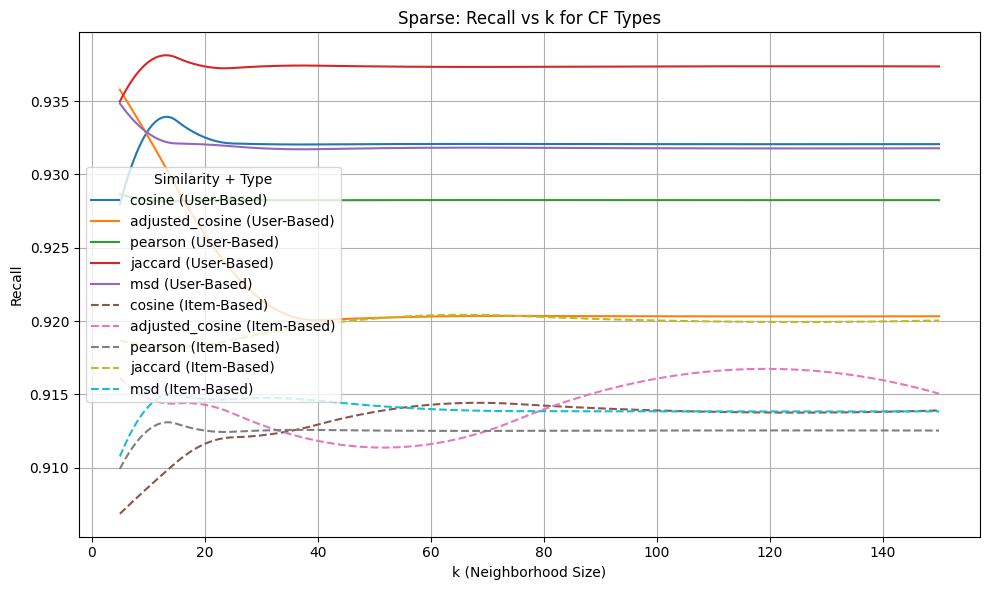

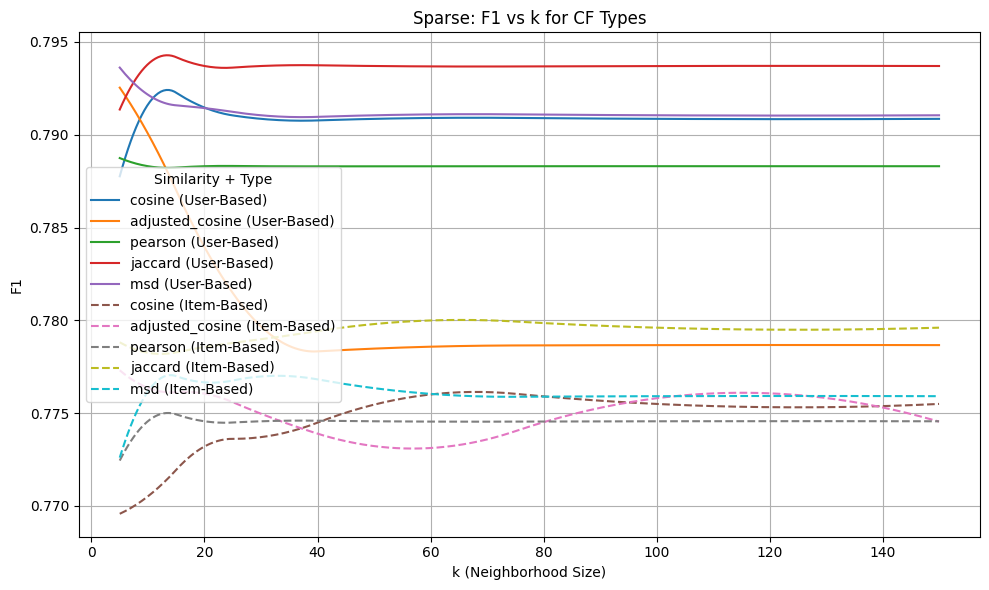

In [30]:
plot_cf_results(sparse_cf_results, title_prefix='Sparse: ')